# 1. Paper metrics: transcripts to conversation geometry

Run this notebook from a fresh kernel, then run `02_statistical_significance.ipynb`.
This is the authoritative preparation notebook for the **current ordinary-PR specification**. Broader geometry plots, earlier statistical models, leave-one-out alternatives and animations are preserved in `../exploratory/static_geometry_exploration.ipynb`.

## Definitions retained from the existing analysis

- **Speaker-centroid distance:** cosine distance between role means, using utterances with **at least five words**.
- **Median / q90 radial distance:** cosine distance to the normalized pooled centroid, using **all nonempty utterances**.
- **Participation ratio:** ordinary centered-covariance PR on **all nonempty utterances**, not row-bias-corrected PR.
- **Count adjustment:** total nonempty utterance count, as in the existing significance analysis. It is not the number of utterances used in the centroid calculation.

These differing selections are preserved for continuity and recorded in the manifest; they are a scientific decision to resolve before final reporting, not corrected silently during reorganization. The alternative PR notebook is not a prerequisite.

Outputs go to `outputs/paper/`, keeping historical exploratory exports separate. Plot labels state the variants used. Existing figures in `paper/figures/` are not overwritten.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / "data/wired").is_dir() and (p / "paper").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run from this repository or a notebook directory inside it.")
os.chdir(PROJECT_ROOT)  # Preserve project-relative paths when launched from a subdirectory.
print("Project root:", PROJECT_ROOT)

# Shared project plotting conventions.
import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from plot_style import (
    apply_style, expertise_palette, EXPERTISE_COLORS, LEVEL_LABELS,
    METRIC_LABELS, MODEL_COLORS, MODEL_MARKERS, PRIMARY, NEUTRAL,
    plot_metric_trajectories, save_figure,
)
apply_style()


Project root: /Users/yume/PycharmProjects/horizons_2


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import json
import hashlib
import importlib.metadata
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

SEED = 20260913
random.seed(SEED)
np.random.seed(SEED)
OUTPUT_DIR = PROJECT_ROOT / "outputs/paper"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WIRED_DIR = PROJECT_ROOT / "data/wired"
csv_paths = sorted(WIRED_DIR.glob("wired_*/*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No transcripts under {WIRED_DIR}")
print("Transcript files:", len(csv_paths))

Transcript files: 105


## Load and label the transcripts
One file is one conversation. Speaker 1 is the focal expert; partner expertise comes from the filename suffix. Blank utterances are dropped.

In [3]:
def parse_wired_path(path):
    """
    Example:
    data/wired/wired_astro/wired_astro_12.csv
    """
    folder_name = path.parent.name
    file_stem = path.stem

    video_id = re.sub(r"^wired_", "", folder_name)

    match = re.search(r"_(\d+)$", file_stem)
    file_number = int(match.group(1)) if match else None

    return {
        "dataset": "wired",
        "video_id": video_id,
        "file_number": file_number,
        "conversation_id": file_stem,
        "source_file": str(path.relative_to(PROJECT_ROOT))
    }

In [4]:
raw_frames = []

for path in csv_paths:
    df = pd.read_csv(path)
    metadata = parse_wired_path(path)

    # Preserve original within-file row order
    df["raw_row_id"] = np.arange(len(df))

    for column, value in metadata.items():
        df[column] = value

    raw_frames.append(df)

wired_raw = pd.concat(
    raw_frames,
    ignore_index=True,
    sort=False
)

wired_raw.shape

(6381, 10)

In [5]:
#rename columns, minimally clean text
wired_raw = wired_raw.rename(columns={
    "Speaker": "speaker_raw",
    "Utterance": "text"
})
wired_raw["text"] = (
    wired_raw["text"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

wired_raw = wired_raw[
    wired_raw["text"].notna() &
    wired_raw["text"].ne("")
].copy()

In [6]:
level_map = {
    12: (0, "child"),
    13: (1, "teenager"),
    14: (2, "undergraduate"),
    15: (3, "graduate"),
    16: (4, "expert")
}

In [7]:
wired_raw["level"] = wired_raw["file_number"].map(
    lambda x: level_map[x][0]
)

wired_raw["level_label"] = wired_raw["file_number"].map(
    lambda x: level_map[x][1]
)

In [8]:
#order levels
level_order = [
    "child",
    "teenager",
    "undergraduate",
    "graduate",
    "expert"
]

wired_raw["level_label"] = pd.Categorical(
    wired_raw["level_label"],
    categories=level_order,
    ordered=True
)

In [9]:
is_expert = wired_raw["speaker_raw"].str.contains(r"\bSpeaker\s*1\b", case=False, na=False)
wired_raw["speaker"] = np.where(is_expert, "A", "B")
wired_raw["speaker_role"] = np.where(is_expert, "expert", "partner")

In [10]:
import re
import numpy as np
import pandas as pd


def count_words(text):
    return len(
        re.findall(
            r"\b[\w'-]+\b",
            str(text),
        )
    )


def create_utterances_table(wired_raw):
    """
    Create one canonical row per original transcript utterance.

    The function does not concatenate adjacent utterances.
    """

    utterances = (
        wired_raw
        .copy()
        .reset_index(drop=False)
        .rename(columns={"index": "_original_dataframe_row"})
    )

    # Accommodate either the original CSV column names or the
    # standardized names already present in wired_raw.
    rename_map = {}

    aliases = {
        "Sequence": "sequence",
        "Utterance": "text",
        "Speaker": "speaker_raw",
        "Notes": "notes",
    }

    for old_name, new_name in aliases.items():
        if (
            old_name in utterances.columns
            and new_name not in utterances.columns
        ):
            rename_map[old_name] = new_name

    utterances = utterances.rename(columns=rename_map)

    # If canonical speaker has not already been created, use
    # the original speaker label.
    if "speaker" not in utterances.columns:
        utterances["speaker"] = utterances["speaker_raw"]

    # Stable source order.
    if "sequence" not in utterances.columns:
        utterances["sequence"] = (
            utterances
            .groupby(
                ["dataset", "conversation_id"],
                sort=False,
            )
            .cumcount()
            .add(1)
        )

    utterances["_sequence_numeric"] = pd.to_numeric(
        utterances["sequence"],
        errors="coerce",
    )

    utterances["_sequence_numeric"] = (
        utterances["_sequence_numeric"]
        .fillna(utterances["_original_dataframe_row"])
    )

    conversation_keys = [
        "dataset",
        "conversation_id",
    ]

    sort_columns = [
        *conversation_keys,
        "_sequence_numeric",
        "_original_dataframe_row",
    ]

    utterances = (
        utterances
        .sort_values(
            sort_columns,
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    # Clean text without altering its linguistic contents.
    utterances["text"] = (
        utterances["text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    if utterances["text"].eq("").any():
        empty_rows = utterances.loc[
            utterances["text"].eq(""),
            [
                *conversation_keys,
                "sequence",
            ],
        ]

        raise ValueError(
            "Empty utterance text found:\n"
            + empty_rows.to_string(index=False)
        )

    # Reconstruct turn membership without concatenating anything.
    # A new turn begins whenever the speaker changes.
    speaker_changed = (
        utterances
        .groupby(
            conversation_keys,
            sort=False,
        )["speaker"]
        .transform(
            lambda speakers:
                speakers.ne(speakers.shift())
        )
    )

    utterances["turn_id"] = (
        speaker_changed
        .astype(int)
        .groupby(
            [
                utterances[column]
                for column in conversation_keys
            ]
        )
        .cumsum()
    )

    # Position of the utterance inside its speaker turn.
    utterances["utterance_in_turn"] = (
        utterances
        .groupby(
            [
                *conversation_keys,
                "turn_id",
            ],
            sort=False,
        )
        .cumcount()
        .add(1)
    )

    # Position within the whole conversation.
    utterances["utterance_number"] = (
        utterances
        .groupby(
            conversation_keys,
            sort=False,
        )
        .cumcount()
        .add(1)
    )

    utterances["utterance_id"] = (
        utterances["dataset"].astype(str)
        + "::"
        + utterances["conversation_id"].astype(str)
        + "::utterance_"
        + utterances["utterance_number"]
            .astype(str)
            .str.zfill(3)
    )

    utterances["n_words"] = (
        utterances["text"]
        .map(count_words)
        .astype(int)
    )

    # Keep all utterances in the canonical table. This flag only
    # determines the primary geometry subset later.
    utterances["include_geometry_primary"] = (
        utterances["n_words"] >= 5
    )

    # This index will correspond exactly to rows of E_utterances.
    utterances["embedding_idx"] = np.arange(
        len(utterances),
        dtype=int,
    )

    preferred_columns = [
        "dataset",
        "video_id",
        "conversation_id",
        "file_number",
        "level",
        "level_label",
        "utterance_id",
        "utterance_number",
        "turn_id",
        "utterance_in_turn",
        "sequence",
        "normalized_time",
        "speaker",
        "speaker_raw",
        "speaker_role",
        "text",
        "n_words",
        "include_geometry_primary",
        "embedding_idx",
        "notes",
        "source_file",
        "_original_dataframe_row",
    ]

    # Retain only columns that actually exist in this dataset.
    output_columns = [
        column
        for column in preferred_columns
        if column in utterances.columns
    ]

    return utterances[output_columns].copy()


utterances = create_utterances_table(wired_raw)

utterances.head()

,dataset,video_id,conversation_id,file_number,level,level_label,utterance_id,utterance_number,turn_id,utterance_in_turn,...,speaker,speaker_raw,speaker_role,text,n_words,include_geometry_primary,embedding_idx,notes,source_file,_original_dataframe_row
0,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_001,1,1,1,...,B,Speaker 2 (Genesis - child),partner,what's this,2,False,0,NaN,data/wired/wired_talia/wired_Talia_12.csv,5383
1,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_002,2,2,1,...,A,Speaker 1 (Talia Gershon),expert,yeah what do you think that is,7,True,1,NaN,data/wired/wired_talia/wired_Talia_12.csv,5384
2,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_003,3,3,1,...,B,Speaker 2 (Genesis - child),partner,fancy chandelier,2,False,2,NaN,data/wired/wired_talia/wired_Talia_12.csv,5385
3,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_004,4,4,1,...,A,Speaker 1 (Talia Gershon),expert,i think so too we jokingly call it the chandelier,10,True,3,NaN,data/wired/wired_talia/wired_Talia_12.csv,5386
4,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_005,5,4,2,...,A,Speaker 1 (Talia Gershon),expert,that's real gold you know,5,True,4,NaN,data/wired/wired_talia/wired_Talia_12.csv,5387


## Embed each utterance

The pinned MiniLM revision produces one normalized embedding per canonical utterance. The model must be cached locally or downloaded on the first run. `LOCAL_FILES_ONLY = True` avoids downloads; set it to `False` if you need to fetch this exact revision. Token-limit checks prevent silent truncation. Segment/turn embedding caches from exploratory notebooks are deliberately not substituted for these utterances.

In [11]:
import torch
from sentence_transformers import SentenceTransformer

torch.manual_seed(SEED)
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_REVISION = "c9745ed1d9f207416be6d2e6f8de32d1f16199bf"
LOCAL_FILES_ONLY = True
embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME, revision=EMBEDDING_REVISION,
    local_files_only=LOCAL_FILES_ONLY, device="cpu",
)
print("Embedding dimension:", embedding_model.get_sentence_embedding_dimension())

/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding dimension: 384


In [12]:
# Prepare and validate utterance texts
utterance_texts = utterances["text"].astype(str).tolist()

utterances["n_model_tokens"] = [
    len(
        embedding_model.tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )
    for text in utterance_texts
]

utterances["exceeds_model_limit"] = (
    utterances["n_model_tokens"]
    > embedding_model.max_seq_length
)

if utterances["exceeds_model_limit"].any():
    raise ValueError(
        "At least one utterance exceeds the model's token limit."
    )

# Generate one normalized embedding per utterance
E_utterances = embedding_model.encode(
    utterance_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

E_utterances = np.asarray(E_utterances, dtype=np.float32)

assert E_utterances.shape[0] == len(utterances)
assert np.isfinite(E_utterances).all()
assert np.allclose(
    np.linalg.norm(E_utterances, axis=1),
    1.0,
    atol=1e-5,
)

print("E_utterances shape:", E_utterances.shape)

Batches: 100%|██████████| 200/200 [00:06<00:00, 28.69it/s]


E_utterances shape: (6381, 384)


In [13]:
geometry_utterances = utterances.copy()  # All nonempty utterances for radial geometry and PR.
print("Utterances:", len(geometry_utterances))

Utterances: 6381


## Calculate geometry and speaker-centroid distance

The existing geometry calculator is retained intact to preserve its mathematical checks and definitions. Only the four main outcomes are selected for the paper export. Its additional intermediate metrics are not separately tested here.

In [14]:
import numpy as np
import pandas as pd


def _sample_sd(values):
    """Sample standard deviation, or NaN if only one value exists."""
    values = np.asarray(values)

    if values.size < 2:
        return np.nan

    return float(np.std(values, ddof=1))


def calculate_conversation_geometry(embeddings, n_words=None, n_turns=None, k=5):
    """
    Calculate the complete geometric metric set for one conversation.

    Parameters
    ----------
    embeddings : array-like, shape (n_utterances, embedding_dimension)
        One embedding per utterance.

    n_words : int, optional
        Total number of words in the conversation.

    n_turns : int, optional
        Total number of conversational turns.

    k : int, default=5
        Neighbor rank used for the k-nearest-neighbor statistic.

    Returns
    -------
    scalar_metrics : dict
        Conversation-level scalar metrics suitable for a DataFrame.

    spectrum : dict
        Eigenvalue arrays retained separately for spectral plots.
    """

    X = np.asarray(embeddings, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(
            "embeddings must have shape "
            "(n_utterances, embedding_dimension)"
        )

    if not np.isfinite(X).all():
        raise ValueError("Embeddings contain NaN or infinite values.")

    n, d = X.shape

    if n < 2:
        raise ValueError(
            "At least two utterances are required."
        )

    if not isinstance(k, (int, np.integer)) or k < 1:
        raise ValueError("k must be a positive integer.")

    # ------------------------------------------------------------
    # 1. Normalize embeddings
    # ------------------------------------------------------------

    norms = np.linalg.norm(X, axis=1, keepdims=True)

    if np.any(norms == 0):
        raise ValueError("At least one embedding has zero norm.")

    X_unit = X / norms

    # ------------------------------------------------------------
    # 2. Pairwise cosine similarity and distance
    # ------------------------------------------------------------

    cosine_similarity_matrix = np.clip(
        X_unit @ X_unit.T,
        -1.0,
        1.0,
    )

    cosine_distance_matrix = 1.0 - cosine_similarity_matrix

    # Set the diagonal to exactly zero for neighbor calculations.
    np.fill_diagonal(cosine_distance_matrix, 0.0)

    upper_triangle = np.triu_indices(n, k=1)

    pairwise_similarities = cosine_similarity_matrix[
        upper_triangle
    ]

    pairwise_distances = cosine_distance_matrix[
        upper_triangle
    ]

    n_pairs = len(pairwise_distances)

    sim_q10, sim_median, sim_q90 = np.quantile(
        pairwise_similarities,
        [0.10, 0.50, 0.90],
    )

    dist_q10, dist_median, dist_q90 = np.quantile(
        pairwise_distances,
        [0.10, 0.50, 0.90],
    )

    # ------------------------------------------------------------
    # 3. Centroid concentration
    # ------------------------------------------------------------

    centroid = X_unit.mean(axis=0)

    centroid_resultant_length = float(
        np.linalg.norm(centroid)
    )

    centroid_dispersion_cosine = float(
        1.0 - centroid_resultant_length
    )

    # ------------------------------------------------------------
    # 4. Radial structure
    # ------------------------------------------------------------

    centroid_tolerance = (
        100 * np.finfo(np.float64).eps
    )

    if centroid_resultant_length > centroid_tolerance:
        centroid_direction = (
            centroid / centroid_resultant_length
        )

        radial_distances = np.clip(
            1.0 - X_unit @ centroid_direction,
            0.0,
            2.0,
        )

        radial_distance_mean = float(
            np.mean(radial_distances)
        )

        radial_distance_median = float(
            np.median(radial_distances)
        )

        radial_distance_q90 = float(
            np.quantile(radial_distances, 0.90)
        )

    else:
        # A zero centroid has no defined direction.
        radial_distances = np.full(n, np.nan)
        radial_distance_mean = np.nan
        radial_distance_median = np.nan
        radial_distance_q90 = np.nan

    # ------------------------------------------------------------
    # 5. Local-neighborhood structure
    # ------------------------------------------------------------

    neighbor_distance_matrix = (
        cosine_distance_matrix.copy()
    )

    # Prevent each utterance from selecting itself.
    np.fill_diagonal(
        neighbor_distance_matrix,
        np.inf,
    )

    nearest_neighbor_distances = np.min(
        neighbor_distance_matrix,
        axis=1,
    )

    k_used = min(k, n - 1)

    kth_neighbor_distances = np.partition(
        neighbor_distance_matrix,
        kth=k_used - 1,
        axis=1,
    )[:, k_used - 1]

    # ------------------------------------------------------------
    # 6. Centered covariance spectrum
    # ------------------------------------------------------------

    X_centered = X_unit - centroid

    singular_values = np.linalg.svd(
        X_centered,
        compute_uv=False,
        full_matrices=False,
    )

    # Covariance eigenvalues:
    # lambda_j = s_j^2 / (n - 1)
    eigenvalues = (
        singular_values**2 / (n - 1)
    )

    total_variance = float(
        eigenvalues.sum()
    )

    maximum_available_rank = min(
        n - 1,
        d,
    )

    leading_singular_value = (
        float(singular_values[0])
        if singular_values.size
        else 0.0
    )

    sv_tolerance = (
        max(n, d)
        * np.finfo(np.float64).eps
        * leading_singular_value
    )

    active = singular_values > sv_tolerance

    # ------------------------------------------------------------
    # 7. Spectral metrics
    # ------------------------------------------------------------

    if np.isclose(
        total_variance,
        0.0,
        atol=1e-15,
        rtol=0.0,
    ):
        numerical_rank = 0
        normalized_eigenvalues = np.array([])

        spectral_entropy = np.nan
        spectral_entropy_normalized = np.nan
        spectral_effective_rank = np.nan
        participation_ratio = np.nan
        pc1_variance_share = np.nan

    else:
        numerical_rank = int(active.sum())

        active_eigenvalues = eigenvalues[active]

        normalized_eigenvalues = (
            active_eigenvalues
            / active_eigenvalues.sum()
        )

        # H = -sum(p_j log p_j)
        spectral_entropy = float(
            -np.sum(
                normalized_eigenvalues
                * np.log(normalized_eigenvalues)
            )
        )

        # Effective rank = exp(H)
        spectral_effective_rank = float(
            np.exp(spectral_entropy)
        )

        # PR = 1 / sum(p_j^2)
        participation_ratio = float(
            1.0
            / np.sum(normalized_eigenvalues**2)
        )

        # Proportion of variance explained by PC1
        pc1_variance_share = float(
            eigenvalues[0] / total_variance
        )

        if maximum_available_rank > 1:
            spectral_entropy_normalized = float(
                spectral_entropy
                / np.log(maximum_available_rank)
            )
        else:
            spectral_entropy_normalized = np.nan

    # ------------------------------------------------------------
    # 8. Collect scalar results
    # ------------------------------------------------------------

    scalar_metrics = {
        # Bookkeeping
        "n_utterances": int(n),
        "n_pairs": int(n_pairs),
        "n_words": (
            int(n_words)
            if n_words is not None
            else np.nan
        ),
        "n_turns": (
            int(n_turns)
            if n_turns is not None
            else np.nan
        ),
        "embedding_dimension": int(d),
        "k_used": int(k_used),

        # Pairwise cosine similarity
        "pairwise_cosine_similarity_mean": float(
            np.mean(pairwise_similarities)
        ),
        "pairwise_cosine_similarity_sd": _sample_sd(
            pairwise_similarities
        ),
        "pairwise_cosine_similarity_q10": float(
            sim_q10
        ),
        "pairwise_cosine_similarity_median": float(
            sim_median
        ),
        "pairwise_cosine_similarity_q90": float(
            sim_q90
        ),

        # Centroid concentration
        "centroid_resultant_length": (
            centroid_resultant_length
        ),
        "centroid_dispersion_cosine": (
            centroid_dispersion_cosine
        ),

        # Radial structure
        # The mean is retained mainly as an identity check.
        "radial_distance_mean_check": (
            radial_distance_mean
        ),
        "radial_distance_median": (
            radial_distance_median
        ),
        "radial_distance_q90": (
            radial_distance_q90
        ),

        # Pairwise cosine distance
        "pairwise_distance_mean": float(
            np.mean(pairwise_distances)
        ),
        "pairwise_distance_sd": _sample_sd(
            pairwise_distances
        ),
        "pairwise_distance_q10": float(
            dist_q10
        ),
        "pairwise_distance_median": float(
            dist_median
        ),
        "pairwise_distance_q90": float(
            dist_q90
        ),
        "pairwise_semantic_span": float(
            dist_q90 - dist_q10
        ),

        # Local-neighborhood structure
        "nearest_neighbor_distance_mean": float(
            np.mean(nearest_neighbor_distances)
        ),
        "nearest_neighbor_distance_median": float(
            np.median(nearest_neighbor_distances)
        ),
        "knn_distance_median": float(
            np.median(kth_neighbor_distances)
        ),

        # Covariance-spectrum structure
        "maximum_available_rank": int(
            maximum_available_rank
        ),
        "numerical_rank": int(
            numerical_rank
        ),
        "total_variance": (
            total_variance
        ),
        "spectral_entropy": (
            spectral_entropy
        ),
        "spectral_entropy_normalized": (
            spectral_entropy_normalized
        ),
        "spectral_effective_rank": (
            spectral_effective_rank
        ),
        "participation_ratio": (
            participation_ratio
        ),
        "pc1_variance_share": (
            pc1_variance_share
        ),
    }

    # Retain arrays separately so they do not clutter the DataFrame.
    spectrum = {
        "covariance_eigenvalues": eigenvalues,
        "normalized_eigenvalues": normalized_eigenvalues,
    }

    # ------------------------------------------------------------
    # 9. Mathematical consistency checks
    # ------------------------------------------------------------

    np.testing.assert_allclose(
        scalar_metrics["pairwise_distance_mean"],
        total_variance,
        atol=1e-10,
    )

    np.testing.assert_allclose(
        scalar_metrics[
            "pairwise_cosine_similarity_mean"
        ],
        1.0
        - scalar_metrics["pairwise_distance_mean"],
        atol=1e-10,
    )

    np.testing.assert_allclose(
        scalar_metrics["pairwise_distance_mean"],
        n / (n - 1)
        * (1.0 - centroid_resultant_length**2),
        atol=1e-10,
    )

    if np.isfinite(radial_distance_mean):
        np.testing.assert_allclose(
            radial_distance_mean,
            centroid_dispersion_cosine,
            atol=1e-10,
        )

    return scalar_metrics, spectrum


# ================================================================
# Calculate metrics for every conversation
# ================================================================

geometry_records = []
conversation_spectra = {}

group_columns = [
    "dataset",
    "conversation_id",
]

for group_key, group in geometry_utterances.groupby(
    group_columns,
    sort=False,
    observed=True,
):
    dataset, conversation_id = group_key

    # embedding_idx maps each utterance row to E_utterances.
    embedding_indices = group[
        "embedding_idx"
    ].to_numpy(dtype=int)

    conversation_embeddings = E_utterances[
        embedding_indices
    ]

    scalar_metrics, spectrum = (
        calculate_conversation_geometry(
            conversation_embeddings,
            n_words=group["n_words"].sum(),
            n_turns=group["turn_id"].nunique(),
            k=5,
        )
    )

    row = {
        "dataset": dataset,
        "conversation_id": conversation_id,
    }

    # Preserve useful conversation metadata where available.
    for column in [
        "video_id",
        "file_number",
        "level",
        "level_label",
    ]:
        if column in group.columns:
            row[column] = group[column].iloc[0]

    row.update(scalar_metrics)
    geometry_records.append(row)

    conversation_spectra[
        (dataset, conversation_id)
    ] = spectrum


conversation_geometry = pd.DataFrame(
    geometry_records
)

sort_columns = [
    column
    for column in [
        "level",
        "dataset",
        "conversation_id",
    ]
    if column in conversation_geometry.columns
]

conversation_geometry = (
    conversation_geometry
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

print(
    "Conversations analyzed:",
    len(conversation_geometry),
)

print(
    "Geometry table shape:",
    conversation_geometry.shape,
)

display(conversation_geometry)

Conversations analyzed: 105
Geometry table shape: (105, 39)


,dataset,conversation_id,video_id,file_number,level,level_label,n_utterances,n_pairs,n_words,n_turns,...,nearest_neighbor_distance_median,knn_distance_median,maximum_available_rank,numerical_rank,total_variance,spectral_entropy,spectral_entropy_normalized,spectral_effective_rank,participation_ratio,pc1_variance_share
0,wired,wired_Talia_12,talia,12,0,child,27,351,315,14,...,0.501682,0.730119,26,26,0.825017,2.993523,0.918795,19.955860,16.181812,0.133915
1,wired,wired_astro_12,astro,12,0,child,56,1540,647,23,...,0.399942,0.595853,55,55,0.816119,3.508485,0.875516,33.397623,22.543433,0.121501
2,wired,wired_blockchain_12,blockchain,12,0,child,20,190,191,9,...,0.433820,0.788989,19,19,0.832669,2.693383,0.914736,14.781599,12.488394,0.148911
3,wired,wired_crispr_12,crispr,12,0,child,21,210,152,12,...,0.403874,0.757450,20,18,0.812852,2.639855,0.881205,14.011167,11.503853,0.174152
4,wired,wired_dimension_12,dimension,12,0,child,89,3916,689,52,...,0.310556,0.546307,88,80,0.795924,3.683957,0.822801,39.803569,22.846722,0.144173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,wired,wired_nuclear_16,nuclear,16,4,expert,44,946,849,11,...,0.445602,0.629145,43,43,0.791545,3.391523,0.901713,29.711170,21.622795,0.128743
101,wired,wired_sensing_16,sensing,16,4,expert,56,1540,882,27,...,0.486627,0.652179,55,50,0.829185,3.464621,0.864570,31.964335,21.181875,0.141975
102,wired,wired_sleep_16,sleep,16,4,expert,31,465,823,13,...,0.341957,0.446537,30,30,0.693088,2.986731,0.878141,19.820781,13.797188,0.177302
103,wired,wired_time_16,time,16,4,expert,63,1953,1182,23,...,0.483401,0.622610,62,62,0.801034,3.757115,0.910345,42.824685,31.911495,0.083664


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cosine

required_objects = [
    "utterances",
    "E_utterances",
    "conversation_geometry",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the earlier notebook cells first. Missing: "
        + ", ".join(missing_objects)
    )

embedding_matrix = np.asarray(E_utterances)

print("utterances shape:", utterances.shape)
print("embedding matrix shape:", embedding_matrix.shape)
print("speaker values:")
print(utterances["speaker"].value_counts(dropna=False))
print("speaker_role values:")
print(utterances["speaker_role"].value_counts(dropna=False))

utterances shape: (6381, 23)
embedding matrix shape: (6381, 384)
speaker values:
speaker
A    4063
B    2318
Name: count, dtype: int64
speaker_role values:
speaker_role
expert     4063
partner    2318
Name: count, dtype: int64


In [16]:
# Validate the explicit mapping between table rows and embedding rows.
embedding_indices = (
    utterances["embedding_idx"]
    .dropna()
    .astype(int)
    .to_numpy()
)

if len(embedding_indices) == 0:
    raise ValueError("utterances contains no embedding_idx values.")

if embedding_indices.min() < 0:
    raise ValueError("embedding_idx contains a negative value.")

if embedding_indices.max() >= embedding_matrix.shape[0]:
    raise ValueError(
        f"Maximum embedding_idx is {embedding_indices.max()}, "
        f"but E_utterances has {embedding_matrix.shape[0]} rows."
    )

if utterances["embedding_idx"].duplicated().any():
    raise ValueError("embedding_idx must be unique in utterances.")

if not np.isfinite(embedding_matrix).all():
    raise ValueError("E_utterances contains non-finite values.")

print("Embedding alignment checks passed.")

Embedding alignment checks passed.


In [17]:
# Use the same primary subset as the earlier conversation geometry.
# This handles both Boolean and string representations safely.
include_primary = (
    utterances["include_geometry_primary"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1", "yes"])
)

geometry_utterances = utterances.loc[include_primary].copy()

# Normalize the already-canonical roles defensively.
geometry_utterances["_centroid_role"] = (
    geometry_utterances["speaker_role"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "learner": "partner",
        "speaker a": "expert",
        "a": "expert",
        "speaker b": "partner",
        "b": "partner",
    })
)

unexpected_roles = sorted(
    set(geometry_utterances["_centroid_role"].dropna())
    - {"expert", "partner"}
)

if unexpected_roles:
    raise ValueError(
        "Unrecognized speaker roles: "
        + repr(unexpected_roles)
    )

role_counts = (
    geometry_utterances
    .groupby(
        ["dataset", "conversation_id", "_centroid_role"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
)

missing_role_conversations = role_counts[
    (role_counts.get("expert", 0) == 0)
    | (role_counts.get("partner", 0) == 0)
]

display(role_counts.head())

if not missing_role_conversations.empty:
    display(missing_role_conversations)
    raise ValueError(
        "At least one primary-geometry conversation lacks an expert "
        "or partner. See the displayed table."
    )

print(
    f"Validated {len(role_counts)} conversations; "
    f"all contain both roles."
)

_centroid_role           expert  partner
dataset conversation_id                 
wired   wired_Talia_12       19        1
        wired_Talia_13       37        8
        wired_Talia_14       29        9
        wired_Talia_15       27        8
        wired_Talia_16       16       27

Validated 105 conversations; all contain both roles.


In [18]:
def calculate_speaker_centroid_distance(
    conversation_utterances,
    embeddings,
    role_column="_centroid_role",
    embedding_index_column="embedding_idx",
):
    """Return expert–partner centroid distances for one conversation."""
    expert_indices = (
        conversation_utterances.loc[
            conversation_utterances[role_column].eq("expert"),
            embedding_index_column,
        ]
        .dropna()
        .astype(int)
        .to_numpy()
    )

    partner_indices = (
        conversation_utterances.loc[
            conversation_utterances[role_column].eq("partner"),
            embedding_index_column,
        ]
        .dropna()
        .astype(int)
        .to_numpy()
    )

    if len(expert_indices) == 0 or len(partner_indices) == 0:
        raise ValueError(
            "Each conversation must contain both expert and partner utterances."
        )

    expert_centroid = embeddings[expert_indices].mean(axis=0)
    partner_centroid = embeddings[partner_indices].mean(axis=0)

    return {
        "expert_n_utterances": int(len(expert_indices)),
        "partner_n_utterances": int(len(partner_indices)),
        "speaker_centroid_cosine_distance": float(
            cosine(expert_centroid, partner_centroid)
        ),
        "speaker_centroid_euclidean_distance": float(
            np.linalg.norm(expert_centroid - partner_centroid)
        ),
    }


# Test one conversation before applying the function to all conversations.
first_key, first_group = next(iter(
    geometry_utterances.groupby(
        ["dataset", "conversation_id"],
        observed=True,
        sort=False,
    )
))

print("Test conversation:", first_key)
print(
    calculate_speaker_centroid_distance(
        first_group,
        embedding_matrix,
    )
)

Test conversation: ('wired', 'wired_Talia_12')
{'expert_n_utterances': 19, 'partner_n_utterances': 1, 'speaker_centroid_cosine_distance': 0.46671104431152344, 'speaker_centroid_euclidean_distance': 0.846758246421814}


In [19]:
speaker_centroid_records = []

for (dataset, conversation_id), group in (
    geometry_utterances.groupby(
        ["dataset", "conversation_id"],
        observed=True,
        sort=False,
    )
):
    result = calculate_speaker_centroid_distance(
        conversation_utterances=group,
        embeddings=embedding_matrix,
    )

    speaker_centroid_records.append({
        "dataset": dataset,
        "conversation_id": conversation_id,
        **result,
    })

speaker_centroid_geometry = pd.DataFrame(speaker_centroid_records)

if speaker_centroid_geometry.empty:
    raise ValueError("No conversation-level centroid results were created.")

distance_columns = [
    "speaker_centroid_cosine_distance",
    "speaker_centroid_euclidean_distance",
]

if speaker_centroid_geometry[distance_columns].isna().any().any():
    raise ValueError("Centroid calculation unexpectedly produced NaN.")

display(speaker_centroid_geometry.head())
display(speaker_centroid_geometry[distance_columns].describe())

,dataset,conversation_id,expert_n_utterances,partner_n_utterances,speaker_centroid_cosine_distance,speaker_centroid_euclidean_distance
0,wired,wired_Talia_12,19,1,0.466711,0.846758
1,wired,wired_Talia_13,37,8,0.463972,0.469025
2,wired,wired_Talia_14,29,9,0.239723,0.367751
3,wired,wired_Talia_15,27,8,0.233536,0.395115
4,wired,wired_Talia_16,16,27,0.101308,0.287101


,speaker_centroid_cosine_distance,speaker_centroid_euclidean_distance
count,105.000000,105.000000
mean,0.241214,0.369261
std,0.114057,0.122493
min,0.075563,0.185967
25%,0.160204,0.297549
50%,0.230380,0.348282
75%,0.281255,0.406411
max,0.798182,1.027540


In [20]:
# Merge by dataset and conversation_id to avoid accidental cross-dataset matches.
centroid_output_columns = [
    "expert_n_utterances",
    "partner_n_utterances",
    "speaker_centroid_cosine_distance",
    "speaker_centroid_euclidean_distance",
]

conversation_geometry = conversation_geometry.drop(
    columns=[
        column for column in centroid_output_columns
        if column in conversation_geometry.columns
    ],
    errors="ignore",
)

conversation_geometry = conversation_geometry.merge(
    speaker_centroid_geometry,
    on=["dataset", "conversation_id"],
    how="left",
    validate="one_to_one",
)

missing_after_merge = conversation_geometry[
    "speaker_centroid_cosine_distance"
].isna()

print(
    f"Merged centroid metrics into {len(conversation_geometry)} conversations."
)
print("Missing after merge:", int(missing_after_merge.sum()))

if missing_after_merge.any():
    display(
        conversation_geometry.loc[
            missing_after_merge,
            ["dataset", "conversation_id", "level_label"],
        ]
    )
    raise ValueError(
        "Some conversation_geometry rows did not match centroid results."
    )

display(
    conversation_geometry[
        [
            "dataset",
            "video_id",
            "conversation_id",
            "level_label",
            "expert_n_utterances",
            "partner_n_utterances",
            "speaker_centroid_cosine_distance",
        ]
    ].head()
)

Merged centroid metrics into 105 conversations.
Missing after merge: 0


,dataset,video_id,conversation_id,level_label,expert_n_utterances,partner_n_utterances,speaker_centroid_cosine_distance
0,wired,talia,wired_Talia_12,child,19,1,0.466711
1,wired,astro,wired_astro_12,child,35,11,0.170952
2,wired,blockchain,wired_blockchain_12,child,11,4,0.368993
3,wired,crispr,wired_crispr_12,child,12,1,0.798182
4,wired,dimension,wired_dimension_12,child,46,15,0.241155


## Validate and export the four outcomes

In [21]:
METRICS = {
    "speaker_centroid_cosine_distance": "Speaker-centroid distance (≥5-word utterances)",
    "radial_distance_median": "Median radial distance (all utterances)",
    "radial_distance_q90": "Q90 radial distance (all utterances)",
    "participation_ratio": "Ordinary participation ratio (all utterances)",
}
columns = ["dataset", "conversation_id", "video_id", "file_number", "level", "level_label",
           "n_utterances", "expert_n_utterances", "partner_n_utterances", *METRICS]
paper_metrics = conversation_geometry[columns].copy()
assert not paper_metrics.duplicated(["dataset", "conversation_id"]).any()
assert np.isfinite(paper_metrics[list(METRICS)]).all().all()
coverage = paper_metrics.groupby(["dataset", "video_id"], observed=True)["level"].agg(set)
assert coverage.map(lambda levels: levels == set(range(5))).all(), "Incomplete five-level video sets"
paper_metrics.to_csv(OUTPUT_DIR / "conversation_metrics.csv", index=False)
utterances.to_csv(OUTPUT_DIR / "utterances_with_embedding_index.csv", index=False)
np.save(OUTPUT_DIR / "utterance_embeddings.npy", E_utterances)
display(paper_metrics.groupby("level_label", observed=True)[list(METRICS)].mean())
print("Exported", len(paper_metrics), "conversations across", len(coverage), "videos.")

manifest = {
    "model": EMBEDDING_MODEL_NAME, "model_revision": EMBEDDING_REVISION, "device": "cpu", "seed": SEED,
    "n_utterances": len(utterances), "n_conversations": len(paper_metrics), "n_videos": len(coverage),
    "metric_definitions": METRICS,
    "centroid_selection": "n_words >= 5", "radial_and_pr_selection": "all nonempty utterances",
    "radial_variant": "full pooled centroid, not leave-one-out",
    "pr_variant": "ordinary centered covariance, not row-bias-corrected",
    "count_covariate": "total nonempty utterances (including those below 5 words)",
    "transcript_sha256": {str(p.relative_to(PROJECT_ROOT)): hashlib.sha256(p.read_bytes()).hexdigest() for p in csv_paths},
    "metrics_sha256": hashlib.sha256((OUTPUT_DIR / "conversation_metrics.csv").read_bytes()).hexdigest(),
    "packages": {p: importlib.metadata.version(p) for p in ["numpy", "pandas", "scipy", "sentence-transformers", "torch"]},
}
(OUTPUT_DIR / "metrics_manifest.json").write_text(json.dumps(manifest, indent=2))

,speaker_centroid_cosine_distance,radial_distance_median,radial_distance_q90,participation_ratio
level_label,,,,
child,0.314863,0.537081,0.696317,19.850426
expert,0.161380,0.521871,0.714981,27.948098
graduate,0.197487,0.530420,0.716195,22.822692
teenager,0.306119,0.532506,0.703019,20.750471
undergraduate,0.226222,0.525567,0.715920,23.400500


Exported 105 conversations across 21 videos.


13710

## Main descriptive plots
Gray lines connect the same video across partner expertise levels. Colored lines are descriptive across-video means, not inferential confidence intervals. Statistical inference is in notebook 02.

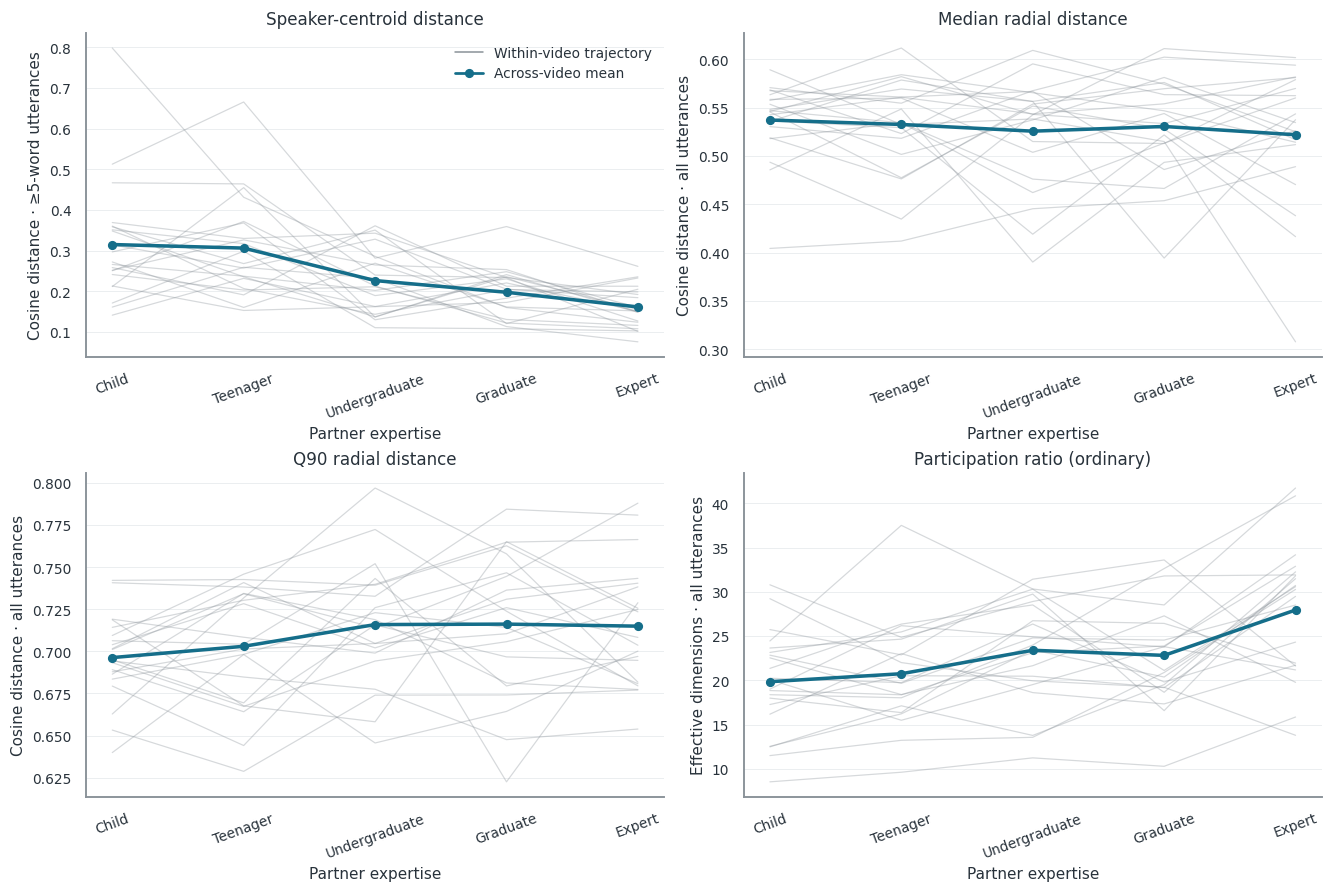

In [22]:
fig, axes = plot_metric_trajectories(paper_metrics)
save_figure(fig, OUTPUT_DIR / "main_metric_trajectories.png")
plt.show()

# K-subspaces